# Assignment 3 - Data Visualization Final Project
Dataset: Toronto Beaches Water Quality (2023)

Source: City of Toronto Open Data Portal

URL: https://open.toronto.ca/dataset/toronto-beaches-water-quality/

License: Open Government Licence - Toronto


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np

In [5]:
# Load dataset 
df = pd.read_csv("toronto_beaches_water_quality.csv")
df["Date"] = pd.to_datetime(df["collectionDate"])  # Ensure Date column is datetime type

# Quick data check
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Dataset shape: (108284, 9)
Columns: ['_id', 'beachId', 'beachName', 'siteName', 'collectionDate', 'eColi', 'comments', 'geometry', 'Date']
   _id  beachId                     beachName siteName collectionDate  eColi  \
0    1        1  Marie Curtis Park East Beach      29W     2025-09-08    NaN   
1    2        1  Marie Curtis Park East Beach      33W     2025-09-08    NaN   
2    3        1  Marie Curtis Park East Beach      32W     2025-09-08    NaN   
3    4        1  Marie Curtis Park East Beach      31W     2025-09-08    NaN   
4    5        1  Marie Curtis Park East Beach      30W     2025-09-08    NaN   

  comments                                           geometry       Date  
0      NaN  {"coordinates": [[-79.539696, 43.58592]], "typ... 2025-09-08  
1      NaN  {"coordinates": [[-79.540886, 43.58486]], "typ... 2025-09-08  
2      NaN  {"coordinates": [[-79.54056, 43.58511]], "type... 2025-09-08  
3      NaN  {"coordinates": [[-79.54039, 43.585304]], "typ... 2025-09-08  
4    

Visualization 1 saved: a3_plot1.png


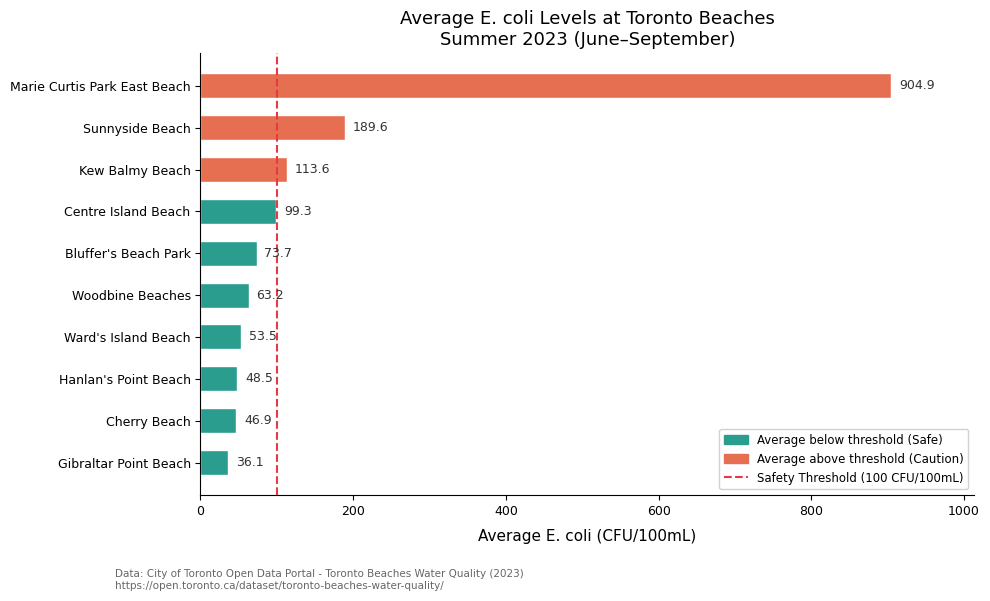

In [24]:
avg_ecoli = (
    df.groupby("beachName")["eColi"]
      .mean()
      .sort_values()
)

threshold = 100

bar_colors = ["#2a9d8f" if x <= threshold else "#e76f51" for x in avg_ecoli]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    avg_ecoli.index,
    avg_ecoli,
    color=bar_colors,
    edgecolor="white",
    height=0.6
)

ax.axvline(threshold, color="#e63946", linestyle="--", linewidth=1.5)

# Use a data-based x limit so large values don't get cut off
x_max = avg_ecoli.max() * 1.12
ax.set_xlim(0, x_max)

# Add labels, with spacing based on the chart width
label_offset = x_max * 0.01

for bar, value in zip(bars, avg_ecoli):
    ax.text(
        value + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333"
    )

ax.set_title(
    "Average E. coli Levels at Toronto Beaches\nSummer 2023 (June–September)",
    fontsize=13,
)

ax.set_xlabel("Average E. coli (CFU/100mL)", fontsize=11, labelpad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)

legend_items = [
    mpatches.Patch(color="#2a9d8f", label="Average below threshold (Safe)"),
    mpatches.Patch(color="#e76f51", label="Average above threshold (Caution)"),
    plt.Line2D(
        [0], [0],
        color="#e63946",
        linestyle="--",
        linewidth=1.5,
        label="Safety Threshold (100 CFU/100mL)"
    )
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=8.5,
    framealpha=0.9
)

fig.text(
    0.12,
    0.01,
    "Data: City of Toronto Open Data Portal - Toronto Beaches Water Quality (2023)\n"
    "https://open.toronto.ca/dataset/toronto-beaches-water-quality/",
    fontsize=7.5,
    color="#666666"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# save plot as a3_plot1.png
plt.savefig("a3_plot1.png", dpi=150, bbox_inches="tight")
print("Visualization 1 saved: a3_plot1.png")
plt.show()